# **Product Recognition of Food Products**

## Image Processing and Computer Vision - Assignment Module \#1


Contacts:

- Prof. Giuseppe Lisanti -> giuseppe.lisanti@unibo.it
- Prof. Samuele Salti -> samuele.salti@unibo.it
- Alex Costanzino -> alex.costanzino@unibo.it
- Francesco Ballerini -> francesco.ballerini4@unibo.it


Computer vision-based object detection techniques can be applied in super market settings to build a system that can identify products on store shelves.
An example of how this system could be used would be to assist visually impaired customers or automate common store management tasks like detecting low-stock or misplaced products, given an image of a shelf in a store.

## Task
Develop a computer vision system that, given a reference image for each product, is able to identify such product from one picture of a store shelf.

<figure>
<a href="https://imgbb.com/">
  <center>
  <img src="https://i.ibb.co/TwkMWnH/Screenshot-2024-04-04-at-14-54-51.png" alt="Screenshot-2024-04-04-at-14-54-51" border="0" width="300" />
</a>
</figure>

For each type of product displayed in the
shelf the system should report:
1. Number of instances;
1. Dimension of each instance (width and height in pixel of the bounding box that enclose them);
1. Position in the image reference system of each instance (center of the bounding box that enclose them).

#### Example of expected output
```
Product 0 - 2 instance found:
  Instance 1 {position: (256, 328), width: 57px, height: 80px}
  Instance 2 {position: (311, 328), width: 57px, height: 80px}
Product 1 – 1 instance found:
.
.
.
```

### Track A - Single Instance Detection
Develop an object detection system to identify single instance of products given one reference image for each item and a scene image.

The system should be able to correctly identify all the product in the shelves
image.

### Track B - Multiple Instances Detection
In addition to what achieved at step A, the system should also be able to detect multiple instances of the same product.

## Data
Two folders of images are provided:
* **Models**: contains one reference image for each product that the system should be able to identify.
* **Scenes**: contains different shelve pictures to test the developed algorithm in different scenarios. The images contained in this folder are corrupted by noise.

#### Track A - Single Instance Detection
* **Models**: {ref1.png to ref14.png}.
* **Scenes**: {scene1.png to scene5.png}.

#### Track B - Multiple Instances Detection
* **Models**: {ref15.png to ref27.png}.
* **Scenes**: {scene6.png to scene12.png}.

In [30]:
from google.colab import drive
drive.mount('/content/drive')

!cp -r /content/drive/MyDrive/AssignmentsIPCV/dataset.zip ./
!unzip dataset.zip

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Archive:  dataset.zip
replace __MACOSX/._dataset? [y]es, [n]o, [A]ll, [N]one, [r]ename: 

## Evaluation criteria
1. **Procedural correctness**. There are several ways to solve the assignment. Design your own sound approach and justify every decision you make;

2. **Clarity and conciseness**. Present your work in a readable way: format your code and comment every important step;

3. **Correctness of results**. Try to solve as many instances as possible. You should be able to solve all the instances of the assignment, however, a thoroughly justified and sound procedure with a lower number of solved instances will be valued **more** than a poorly designed approach.

In [1]:
import cv2
import matplotlib.pyplot as plt
import os
import numpy as np

TRACK A - SINGLE INSTANCE DETECTION

In [2]:
def create_list_of_paths(directory):
    image_files = os.listdir(directory)
    image_files.sort(key=lambda x: int(''.join(filter(str.isdigit, x))))
    image_files = [os.path.join(directory, image_file) for image_file in image_files]
    return image_files

In [21]:
images_directory = '/content/dataset'
reference_directory = os.path.join(images_directory, 'models')
scene_directory =  os.path.join(images_directory, 'scenes')
reference_files = create_list_of_paths(reference_directory)
scene_files = create_list_of_paths(scene_directory)

In [41]:
class Image:
    def __init__(self, path, is_colored, preprocess):
        image = cv2.imread(path, is_colored)
        if preprocess:
          self.image = cv2.bilateralFilter(image, 15, 350, 350)
          #m = cv2.cvtColor(self.image, cv2.COLOR_BGR2RGB)
          #plt.imshow(m)
          #plt.show()
        else:
          self.image = image
        self.label = path.split("/")[-1]

In [23]:
def create_subset_of_images(list_of_paths, start, end, is_colored, preprocess = False):
  assert start < end and start >= 0 and end <= len(list_of_paths)
  subset_of_paths = list_of_paths[start:end]
  subset_of_images = []
  for path in subset_of_paths:
    image = Image(path, is_colored, preprocess)
    subset_of_images.append(image)
  return subset_of_images

In [42]:
track_A_reference_images = create_subset_of_images(reference_files, start=0, end=14, is_colored =1)
track_A_scene_images = create_subset_of_images(scene_files, start=0, end=5, is_colored=1, preprocess =True)
track_B_reference_images = create_subset_of_images(reference_files, start=14, end=27, is_colored=1)
track_B_scene_images = create_subset_of_images(scene_files,  start=5, end=12, is_colored=1, preprocess=True)

KeyboardInterrupt: 

CAPISCI come funziona questa cosa del sift detector che mi sa lavora solo su grayscale images, pero' magari posso fare shift detector per ogni channel (adesso vediamo se e' possibile). Per adesso tengo tutto a grayscale

In [25]:
def compute_flann_2NN_matching(flann_index_kdtree, trees, checks, k):
  index_params = dict(algorithm = flann_index_kdtree, trees = trees)
  search_params = dict(checks = checks)
  flann = cv2.FlannBasedMatcher(index_params, search_params)
  def compute_flan(des_reference, des_scene):
      matches =  flann.knnMatch(des_reference,des_scene,k=k)
      good = []
      for m,n in matches:
          if m.distance < 0.7*n.distance:
              good.append(m)
      return good
  return compute_flan

In [26]:
lambda_matcher = compute_flann_2NN_matching(flann_index_kdtree = 1, trees = 8, checks = 100, k =2)

In [27]:
def compute_homography(homography_method, ransacReprojThreshold):
  def find_homography(matches, kp_reference, kp_scene):
    src_pts = np.float32([ kp_reference[m.queryIdx].pt for m in matches ]).reshape(-1,1,2)
    dst_pts = np.float32([ kp_scene[m.trainIdx].pt for m in matches ]).reshape(-1,1,2)
    M, mask = cv2.findHomography(src_pts, dst_pts, homography_method, ransacReprojThreshold)
    matchesMask = mask.ravel().tolist()
    return M, matchesMask
    ## POTREI FERMARMI QUI, ritornare la M con la mask e poi TUTTE INSIEME SULLA STESSA TARGET IMAGE outputtare le bounding boxes per ogni
    ## item (solo nel caso in cui ho un matchovviamente)
  return find_homography


In [28]:
def compute_box(reference_image, scene_image, M):
  h,w,_ = reference_image.shape
  pts = np.float32([ [0,0],[0,h-1],[w-1,h-1],[w-1,0] ]).reshape(-1,1,2)
  dst = cv2.perspectiveTransform(pts,M)
  return dst


In [29]:
lambda_homography = compute_homography(homography_method = cv2.RANSAC, ransacReprojThreshold = 5.0)

In [30]:
def sift_instance_detection(reference, scene, perform_matcher, min_match_count, compute_homography):
  reference_image, scene_image, reference_label = reference.image, scene.image, reference.label
  sift = cv2.xfeatures2d.SIFT_create()
  kp_reference = sift.detect(reference_image)
  kp_scene = sift.detect(scene_image)
  kp_reference, des_reference = sift.compute(reference_image, kp_reference)
  kp_scene, des_scene = sift.compute(scene_image, kp_scene)
  matches = perform_matcher(des_reference,des_scene)
  print(len(matches))
  if len(matches)<=min_match_count:
    return None
  M, mask = compute_homography(matches, kp_reference, kp_scene)
  dst = compute_box(reference_image, scene_image, M)
  return dst

# TODO
1. deblurra tutte le *scene images* con qualcosa: o usi un bel bilateral filter, o usi un median filter, o fai una combo di filters. Se noti punti bianchi puoi prima fare median filter per rimuoverli e poi bilateral/gaussian filter (penso bilateral e' comunque la way). Controlla pure non-local means filter che  puo' essere interessante
2. per matchare piu' di un elemento in una scena, segui il procedimento visto fin'ora fino al punto in cui hai M. Questa permettera' di fare un warp della reference image nella *scene image*. A questo punto, posso slidare sulla *scene image* utilizzando la *reference image warpata*. Posso fare in due modi in verita': o applico un matching usando similarity functions, OPPURE applico una shape matching (quindi facendo passare l'immagine warpata in un algoritmo di edge detection, calcolando poi per alcuni punti il gradiente).

3. DUBBI: non so se e' possibile runnare un salient point matching basato su differenti colori rgb per poi farne la media insomma ma mi sembra assurdo.
Non so se ci sono benefici nel far prima un edge detection, prima del salient point matching (ma dubito non ha molto senso).
Non so se ha senso in nessun momento fare edge detection in verita'.

In [31]:
def draw_bounding_box(bounding_box, reference_label, img_bounding_boxes):
    random_color = np.random.randint(0, 256, size=(3,)).tolist()
    label_shift = 60
    img_bounding_boxes = cv2.polylines(img_bounding_boxes,[np.int32(bounding_box)],True,random_color,10, cv2.LINE_AA)
    label_position = (int(bounding_box[0][0][0]) + label_shift, int(bounding_box[0][0][1]) + label_shift)
    cv2.putText(img_bounding_boxes, reference_label, label_position, cv2.FONT_HERSHEY_SIMPLEX, fontScale=2.0, color= (0,0,0), thickness =3)
    return img_bounding_boxes

In [32]:
def compute_box_description(box_coordinates):
    x_values = [coord[0][0] for coord in box_coordinates]
    y_values = [coord[0][1] for coord in box_coordinates]
    x_sum = sum(x_values)
    y_sum = sum(y_values)
    num_coords = len(box_coordinates)
    center_x = round(x_sum / num_coords,3)
    center_y = round(y_sum / num_coords,3)
    width = round(max(x_values) - min(x_values),3)
    height = round(max(y_values) - min(y_values),3)
    return (center_x, center_y), width, height

In [33]:
def find_items_in_scene_image(min_match_count, reference_images, scene_image, lambda_matcher, lambda_homography):
  image_bounding_boxes = scene_image.image.copy()
  for reference_image in reference_images:
    dst = sift_instance_detection(reference_image, scene_image, lambda_matcher, min_match_count, lambda_homography)
    if dst is not None:
      center, width, height =  compute_box_description(dst)
      print(f"   Item found {reference_image.label} : [ position: {center}, width: {width} px, height: {height} px ]")
      image_bounding_boxes = draw_bounding_box(dst, reference_image.label, image_bounding_boxes)
  image_bounding_boxes_rgb = cv2.cvtColor(image_bounding_boxes, cv2.COLOR_BGR2RGB)
  plt.imshow(image_bounding_boxes_rgb)
  plt.show()

In [34]:
def find_items_in_scene_images(min_match_count, reference_images, scene_images, lambda_matcher, lambda_homography):
  for scene_image in scene_images:
    print(f'Scene image {scene_image.label}')
    find_items_in_scene_image(min_match_count, reference_images, scene_image, lambda_matcher, lambda_homography)

21
20
53
35
23
55
57
92
33
24
18
7
30
18


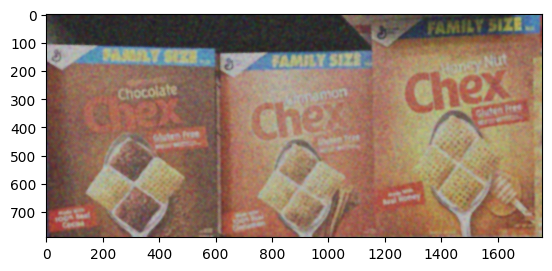

In [40]:
min_match_count = 100
find_items_in_scene_image(min_match_count, track_A_reference_images, track_A_scene_images[2], lambda_matcher, lambda_homography)

Scene image scene1.png
480
   Item found ref1.png : [ position: (412.084, 538.727), width: 802.5419921875 px, height: 1048.9019775390625 px ]
315
   Item found ref2.png : [ position: (1248.062, 533.401), width: 803.135986328125 px, height: 1049.7760009765625 px ]
30
23
72
19
11
23
14
22
8
5
14
52


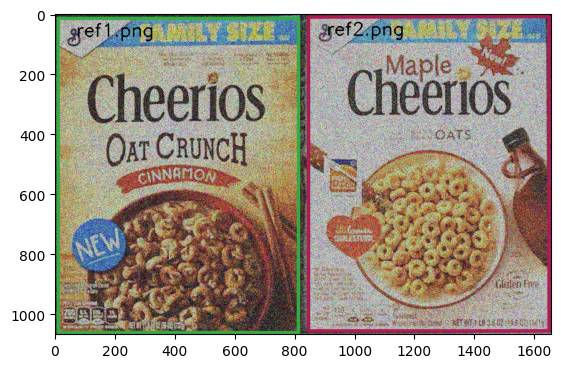

Scene image scene2.png
56
75
172
   Item found ref3.png : [ position: (306.094, 494.058), width: 603.9110107421875 px, height: 940.1599731445312 px ]
183
   Item found ref4.png : [ position: (927.471, 482.709), width: 633.7630004882812 px, height: 950.8389892578125 px ]
184
   Item found ref5.png : [ position: (1527.872, 450.19), width: 560.593994140625 px, height: 843.9080200195312 px ]
9
23
59
37
34
9
6
17
49


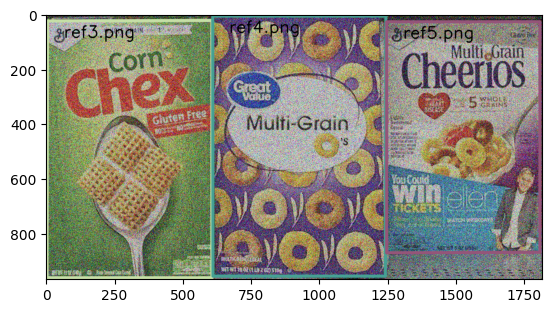

Scene image scene3.png
24
14
45
13
6
61
56
67
22
21
8
3
5


KeyboardInterrupt: 

In [67]:
min_match_count = 100
find_items_in_scene_images(min_match_count, track_A_reference_images, track_A_scene_images, lambda_matcher, lambda_homography)